### LangGraph Blog - Separate Vector DB

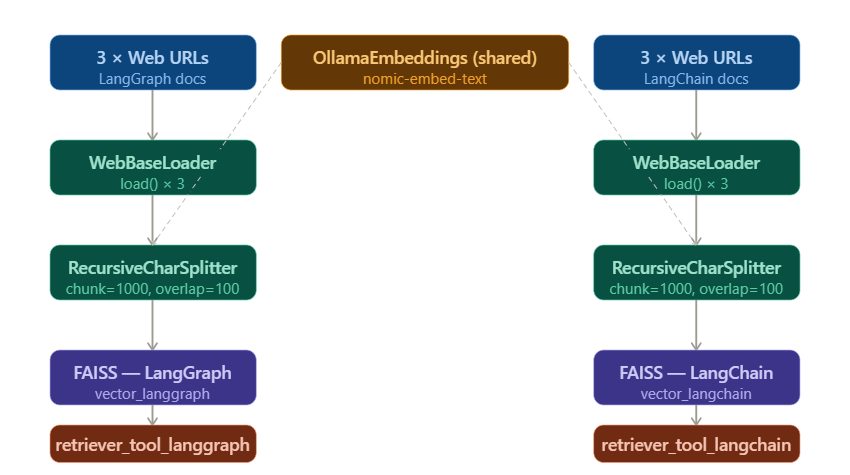

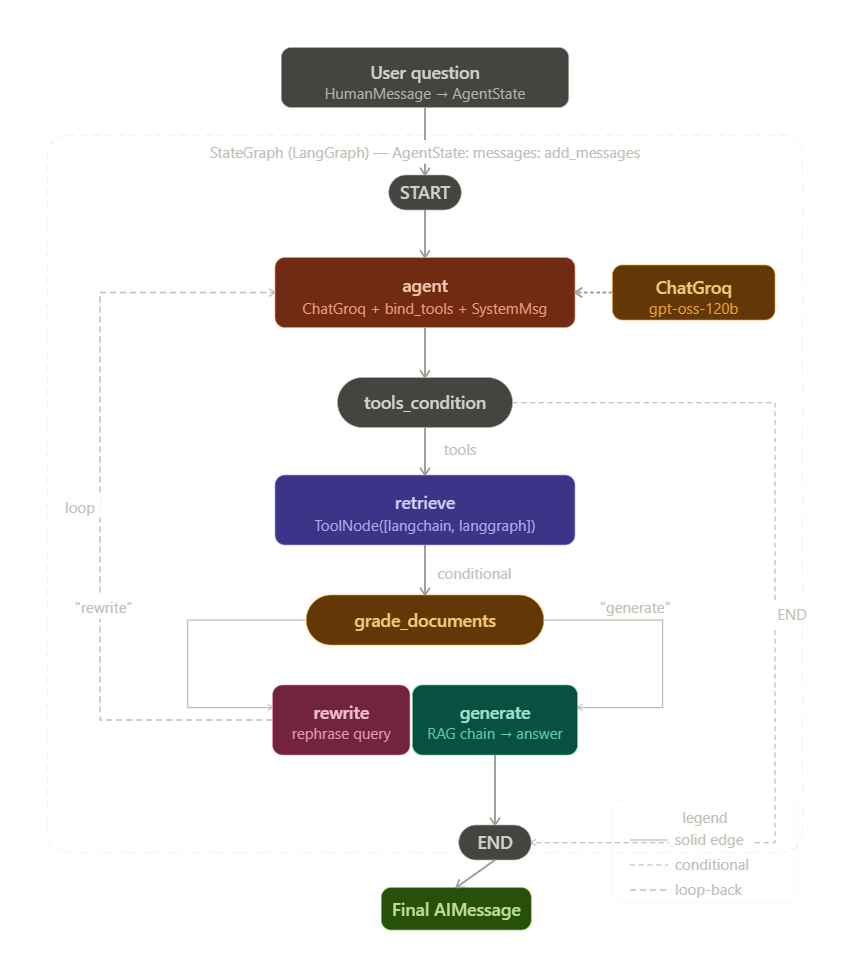

In [73]:
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
import os
from dotenv import load_dotenv

load_dotenv()

embedding = OllamaEmbeddings(model='nomic-embed-text')

urls = [
    'https://docs.langchain.com/oss/python/langgraph/overview',
    'https://docs.langchain.com/oss/python/langgraph/workflows-agents',
    'https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api'
]

docs_list = []
for url in urls:
    loader = WebBaseLoader(url)
    docs_list.extend(loader.load())
    
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_split = text_splitter.split_documents(docs_list)
vector_langgraph = FAISS.from_documents(doc_split, embedding)
retriever_langgraph = vector_langgraph.as_retriever()

In [74]:
# Retriever to Retriever Tools
from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool_langgraph = create_retriever_tool(
    retriever=retriever_langgraph,
    name='retriever_vector_langgraph_blog',
    description='Search and run information about LangGraph'
)

### LangChain Blog - Separate Vector DB

In [75]:
urls = [
    'https://docs.langchain.com/oss/python/langchain/overview',
    'https://docs.langchain.com/oss/python/langchain/knowledge-base',
    'https://docs.langchain.com/oss/python/langchain/rag'
]

docs_list = []
for url in urls:
    loader = WebBaseLoader(url)
    docs_list.extend(loader.load())
    
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_split = text_splitter.split_documents(docs_list)
vector_langchain = FAISS.from_documents(doc_split, embedding)
retriever_langchain = vector_langchain.as_retriever()

In [76]:
# Retriever to Retriever Tools
from langchain_classic.tools.retriever import create_retriever_tool

retriever_tool_langchain = create_retriever_tool(
    retriever=retriever_langchain,
    name='retriever_vector_langchain_blog',
    description='Search and run information about LangChain'
)

### Tools - Combining [LangGraph + LangChain]

In [77]:
tools = [retriever_tool_langgraph, retriever_tool_langchain]

### Workflow

In [78]:
from typing import Annotated, TypedDict, Sequence, Literal
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [79]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')

llm = ChatGroq(model='openai/gpt-oss-120b')

In [ ]:
from langchain_core.messages import SystemMessage

# Agent - Node
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given the question,
    it will decide to retrieve using the retriever tool, or simply end.
    
    Args:
        state (messages): The current state
        
    Returns:
        dict: The updated state with the agent response appended to messages
    """
    
    
    print('➡️➡️➡️➡️ Call Agent ⬅️⬅️⬅️⬅️')
    
    messages = state['messages']
    
    system_msg = SystemMessage(content="""
        You are an AI assistant.
        You MUST use the provided tools to answer questions about LangChain or LangGraph.
        Do NOT answer from your own knowledge.
    """)
    
    model = ChatGroq(model='openai/gpt-oss-120b')
    model = model.bind_tools(tools)
    response = model.invoke(
        [system_msg] + messages,
        tool_choice='auto'
    )
    
    print("Tool calls:", response.tool_calls)  # 🔍 Debug
    
    return {'messages': [response]}

In [89]:
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate

# Grade Documents - Edge
def grade_documents(state) -> Literal['generate', 'rewrite']:
    """
    Determines whether the retrieved documents are relevant to the question.
    
    Args:
        state (message): The current state
    
    Return:
        str: A decision for whether the documents are relevant or not
    """
    
    print('➡️➡️➡️➡️ Checking Relevance ⬅️⬅️⬅️⬅️')
    
    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")
        
    # LLM
    model = ChatGroq(model='openai/gpt-oss-120b')
    
    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)
    
    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=['context', 'question']
    )
    
    # Chain
    chain = prompt | llm_with_tool
    
    messages = state['messages']
    last_message = messages[-1]
    
    question = messages[0].content
    docs = last_message.content
    
    score_result = chain.invoke({'question': question, 'context': docs})
    
    score = score_result.binary_score
    
    if score == 'yes':
        print('✅✅✅✅ Decision: Docs Relevant ✅✅✅✅')
        return 'generate'
    else:
        print('❌❌❌❌ Decision: Docs Not Relevant ❌❌❌❌')
        print(f'Printing Score: {score}')
        return 'rewrite'
    

In [90]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

def generate(state):
    print('🧬 Generate')

    messages = state['messages']
    question = messages[0].content
    docs = messages[-1].content   # retrieved docs

    # Prompt
    prompt = ChatPromptTemplate.from_template("""
    Answer the question based only on the context below.

    Context:
    {context}

    Question:
    {question}
    """)

    # LLM
    llm = ChatGroq(model='openai/gpt-oss-120b')

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({
        "context": docs,
        "question": question
    })

    return {
        "messages": messages + [response]   # ✅ IMPORTANT FIX
    }

In [83]:
# from langchain_core.output_parsers import StrOutputParser
# from langchain_classic import hub

# def generate(state):
#     """
#     Generate answer
    
#     Args:
#         state (messages): The current state
        
#     Returns:
#         dict: The updated message
#     """
    
#     print('🧬🧬🧬🧬 Generate 🧬🧬🧬🧬')
    
#     messages = state['messages']
#     question = messages[0].content
#     last_message = messages[-1]
    
#     docs = last_message.content
    
#     # Prompt
#     prompt = hub.pull('rlm/rag-prompt')
    
#     # LLM
#     llm = ChatGroq(model='openai/gpt-oss-120b')
    
#     # Post-Processing
#     def format_docs(docs):
#         return '\n\n'.join(doc.page_content for doc in docs)
    
#     # Chain
#     rag_chain = prompt | llm | StrOutputParser()
    
#     # Run
#     response = rag_chain.invoke({'context': docs, 'question': question})
    
#     return {'messages': response}

In [91]:
from langchain_core.messages import HumanMessage

def rewrite(state):
    """
    Transform the query to produce a better question.
    
    Args:
        state (messages): The current state
        
    Returns:
        Dict: The updated state with re-phrased question
    """
    
    print('➡️➡️➡️➡️ Transform Query ⬅️⬅️⬅️⬅️')
    
    messages = state['messages']
    question = messages[0].content
    
    msg = [
        HumanMessage(content=f'''\n
        Look at the input and try to reason about the underlying semantic intent / meaning. \n
        Here is the initial question:
        \n ------------ \n
        {question}
        \n ------------ \n
        Formulate an improved question: '''
        )
    ]
    
    # Grader
    model = ChatGroq(model='openai/gpt-oss-120b')
    response = model.invoke(msg)
    
    return {'messages': [response]}

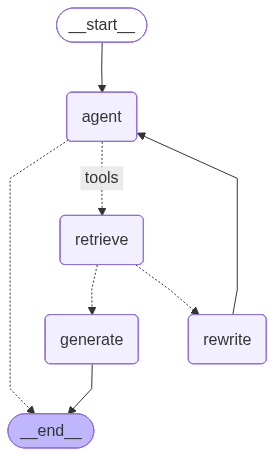

In [92]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes will cycle between
workflow.add_node('agent', agent)
retrieve = ToolNode([retriever_tool_langchain, retriever_tool_langgraph])
workflow.add_node('retrieve', retrieve) # Retrieval Tool
workflow.add_node('rewrite', rewrite) # Re-Writing the question
workflow.add_node('generate', generate) # Generating a response after know the documents are relevant

# Call agent node to decide to retrieve or not
workflow.add_edge(START, 'agent')
# Decide whether to retrieve
workflow.add_conditional_edges(
    'agent', 
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in graph
        'tools': 'retrieve',
        END: END
    }
)

# Edges taken after the 'action' node is called
workflow.add_conditional_edges(
    'retrieve',
    # Assess agent decision
    grade_documents
)

workflow.add_edge('generate', END)
workflow.add_edge('rewrite', 'agent')

# Compile
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({'messages': [HumanMessage(content='Explain LangGraph workflows?')]})

➡️➡️➡️➡️ Call Agent ⬅️⬅️⬅️⬅️
Tool calls: [{'name': 'retriever_vector_langgraph_blog', 'args': {'query': 'LangGraph workflows'}, 'id': 'fc_4e21d182-e569-4208-a2ad-c22ae770ee0a', 'type': 'tool_call'}]
➡️➡️➡️➡️ Checking Relevance ⬅️⬅️⬅️⬅️
✅✅✅✅ Decision: Docs Relevant ✅✅✅✅
🧬 Generate


{'messages': [HumanMessage(content='Explain LangGraph workflows?', additional_kwargs={}, response_metadata={}, id='30272d9a-2e7a-47bf-bbc0-9683f6fed121'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer about LangGraph workflows, using the provided tools to retrieve info. Use retriever_vector_langgraph_blog with query "LangGraph workflows".', 'tool_calls': [{'id': 'fc_4e21d182-e569-4208-a2ad-c22ae770ee0a', 'function': {'arguments': '{"query":"LangGraph workflows"}', 'name': 'retriever_vector_langgraph_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 210, 'total_tokens': 276, 'completion_time': 0.144414873, 'completion_tokens_details': {'reasoning_tokens': 32}, 'prompt_time': 0.008725594, 'prompt_tokens_details': None, 'queue_time': 0.045789005, 'total_time': 0.153140467}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d81b3304b3', 'service_tier': 'on_demand', 'finish_reason': '

In [94]:
graph.invoke({'messages': [HumanMessage(content='Explain What is LangChain?')]})

➡️➡️➡️➡️ Call Agent ⬅️⬅️⬅️⬅️
Tool calls: [{'name': 'retriever_vector_langchain_blog', 'args': {'query': 'What is LangChain?'}, 'id': 'fc_c1e16216-44cd-4ead-bd5f-33b8235bebae', 'type': 'tool_call'}]
➡️➡️➡️➡️ Checking Relevance ⬅️⬅️⬅️⬅️
❌❌❌❌ Decision: Docs Not Relevant ❌❌❌❌
Printing Score: no
➡️➡️➡️➡️ Transform Query ⬅️⬅️⬅️⬅️
➡️➡️➡️➡️ Call Agent ⬅️⬅️⬅️⬅️
Tool calls: [{'name': 'retriever_vector_langchain_blog', 'args': {'query': 'LangChain overview'}, 'id': 'fc_aabd04fb-47d3-4a04-ac9a-dc952c952aef', 'type': 'tool_call'}]
➡️➡️➡️➡️ Checking Relevance ⬅️⬅️⬅️⬅️
❌❌❌❌ Decision: Docs Not Relevant ❌❌❌❌
Printing Score: no
➡️➡️➡️➡️ Transform Query ⬅️⬅️⬅️⬅️
➡️➡️➡️➡️ Call Agent ⬅️⬅️⬅️⬅️
Tool calls: [{'name': 'retriever_vector_langchain_blog', 'args': {'query': 'LangChain framework overview'}, 'id': 'fc_8798a1e2-1682-4a8b-bfbf-971e55e4fc8a', 'type': 'tool_call'}]
➡️➡️➡️➡️ Checking Relevance ⬅️⬅️⬅️⬅️
✅✅✅✅ Decision: Docs Relevant ✅✅✅✅
🧬 Generate


{'messages': [HumanMessage(content='Explain What is LangChain?', additional_kwargs={}, response_metadata={}, id='bd19cbb2-a0d2-419c-b0c8-93875fd34e7e'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Explain What is LangChain?" According to instructions, must use provided tools to answer questions about LangChain or LangGraph. Must not answer from own knowledge. So need to retrieve info via retriever_vector_langchain_blog with appropriate query. Then summarize.\n\nLet\'s call function.', 'tool_calls': [{'id': 'fc_c1e16216-44cd-4ead-bd5f-33b8235bebae', 'function': {'arguments': '{"query":"What is LangChain?"}', 'name': 'retriever_vector_langchain_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 211, 'total_tokens': 306, 'completion_time': 0.201571003, 'completion_tokens_details': {'reasoning_tokens': 60}, 'prompt_time': 0.008188145, 'prompt_tokens_details': None, 'queue_time': 0.045179034, 'tota